# Start

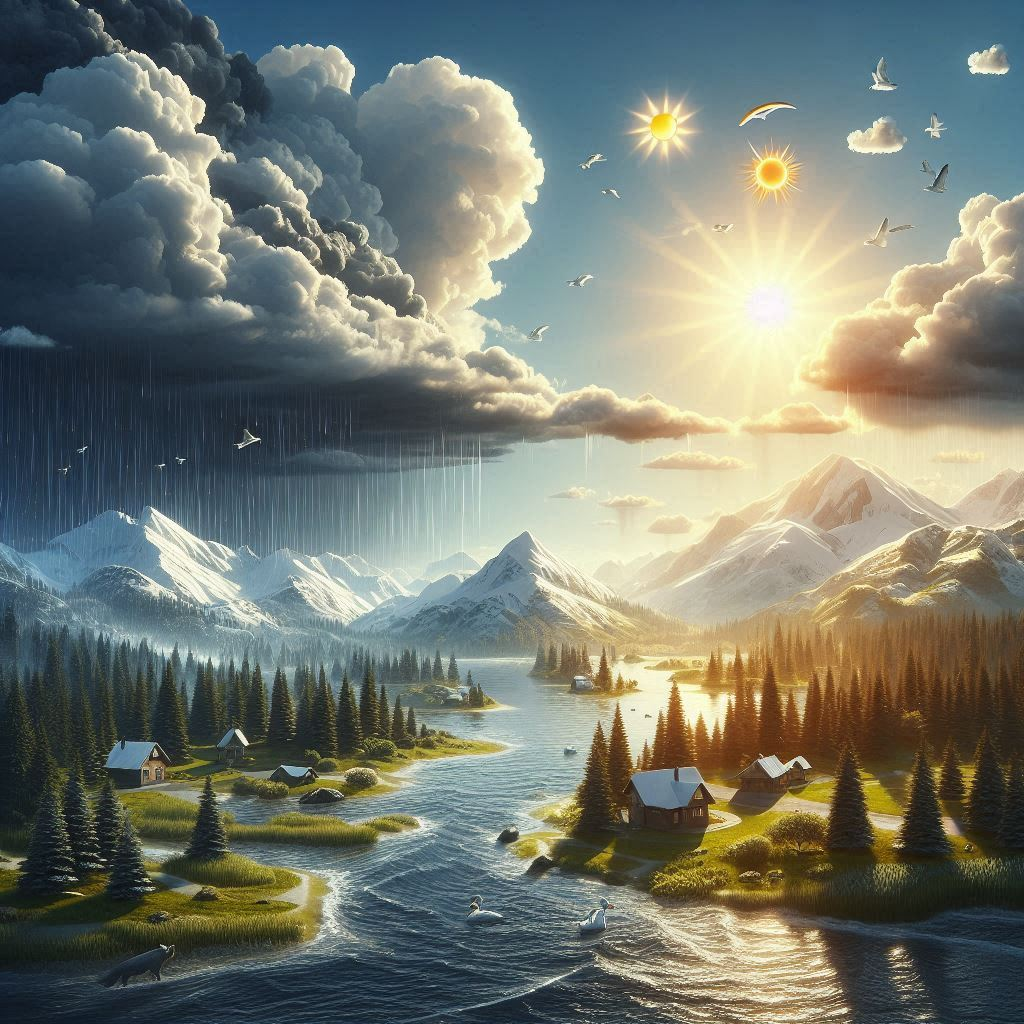









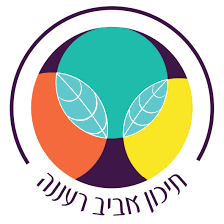


---


# **Information**



**The purpose of the study**
The purpose of my research is to get data on a certain day and try to predict whether it will rain on that day or other events, for example, according to an index called "weather_main" in which there are 4 different types of weather events.



**General Information About the Project and the DataFrame**

**Brief Description of the Database**
The dataset contains historical weather data for Denpasar, Bali, collected over several decades.
This extensive dataset provides detailed weather conditions, including temperature, humidity, pressure, and various precipitation measurements.

---

**Details About the Source of the Data**

Source: Kaggle

Creator: Rudy Hendrawan

Time Frame: January 1, 1990, to January 7, 2020

Versions: Two versions

Last Updated: Four years ago

Link to the Database: [Denpasar Bali Historical Weather Data](https://www.kaggle.com/datasets/cornflake15/denpasarbalihistoricalweatherdata/data)

Details on the Types of Data in the Database
Number of Records (Rows): **264,924**

Number of Columns: **32**

**Column Descriptions:**

**"dt"**: No explanation provided. בדיד

**"dt_iso"**: The date and time of the weather observation. רציף

**"timezone"**: Time zone of the observation. בדיד

**"city_name"**: Name of the city. בדיד

**"temp"**: Temperature (can be used as a feature for classification). רציף

**"lon"**: Longitude of the weather station (can be used as a feature for classification). רציף

**"lat"**: Latitude of the weather station (can be used as a feature for classification). רציף

**"temp_max"**: Maximum temperature recorded (can be used as a feature for classification). רציף

**"temp_min"**: Minimum temperature recorded (can be used as a feature for classification). רציף

**"pressure"**: Atmospheric pressure (can be used as a feature for classification). רציף

**"sea_level"**: Sea level pressure. רציף

**"grnd_level"**: Ground level pressure. רציף

**"humidity"**: Humidity percentage (can be used as a feature for classification). רציף

**"wind_speed"**: Wind speed (can be used as a feature for classification). רציף

**"wind_deg"**: Wind direction in degrees (can be used as a feature for classification). רציף

**"rain_1h"**: Rain volume for the last hour. רציף

**"rain_3h"**: Rain volume for the last 3 hours. רציף

**"rain_6h"**: Rain volume for the last 6 hours. רציף

**"rain_12h"**: Rain volume for the last 12 hours. רציף

**"rain_24h"**: Rain volume for the last 24 hours. רציף

**"rain_today"**: Boolean indicating if it rained today. בדיד

**"snow_1h"**: Snow volume for the last hour. רציף

**"snow_3h"**: Snow volume for the last 3 hours. רציף

**"snow_6h"**: Snow volume for the last 6 hours. רציף

**"snow_12h"**: Snow volume for the last 12 hours. רציף

**"snow_24h"**: Snow volume for the last 24 hours. רציף

**"snow_today"**: Boolean indicating if it snowed today. בדיד

**"clouds_all"**: Cloudiness percentage. רציף

**"weather_id"**: Weather condition ID. בדיד

**"weather_main"**: Main weather condition (can be used as a target for regression). בדיד

**"weather_description"**: Detailed weather description. בדיד

**Classification and Target Features**

Target: "weather_main" (for regression)

**Features for Classification**:

Longitude ("lon")

Latitude ("lat")

Temperature ("temp")

Minimum Temperature ("temp_min")

Maximum Temperature ("temp_max")

Pressure ("pressure")

Humidity ("humidity")

Wind Speed ("wind_speed")

Wind Degree ("wind_deg")

Note: All temperature measurements are in **Celsius**.


# **Data processing**

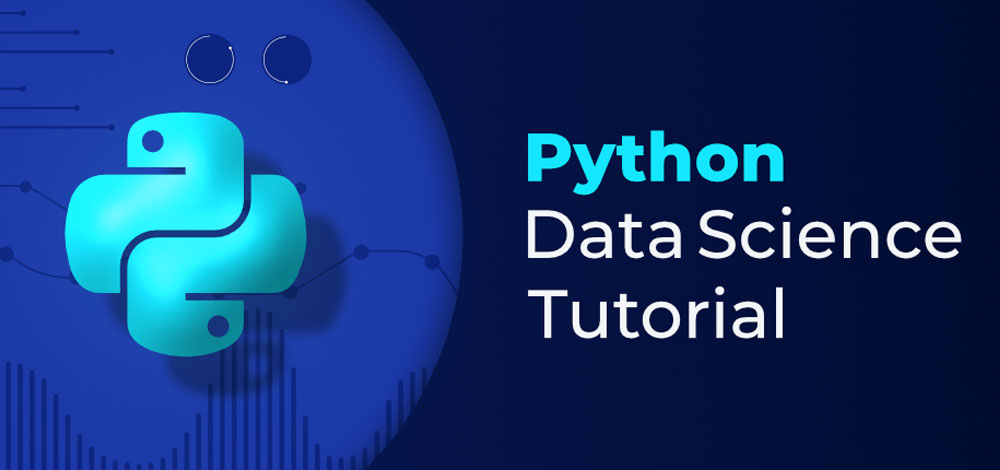

In [ ]:
import numpy as np
import scipy.stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score,precision_score,classification_report
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib import rcParams
from sklearn.preprocessing import MinMaxScaler,StandardScaler,MaxAbsScaler,RobustScaler,QuantileTransformer,PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Markdown as md
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DATA/openweatherdata-denpasar-1990-2020.csv')

In [ ]:
df

,dt,dt_iso,timezone,city_name,lat,lon,temp,temp_min,temp_max,pressure,...,snow_3h,snow_6h,snow_12h,snow_24h,snow_today,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,631152000,1990-01-01 00:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,25.82,25.82,25.82,1010.0,...,NaN,NaN,NaN,NaN,NaN,98,500,Rain,light rain,10d
1,631155600,1990-01-01 01:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,26.20,26.20,26.20,1011.0,...,NaN,NaN,NaN,NaN,NaN,91,500,Rain,light rain,10d
2,631159200,1990-01-01 02:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,26.45,26.45,26.45,1011.0,...,NaN,NaN,NaN,NaN,NaN,94,500,Rain,light rain,10d
3,631162800,1990-01-01 03:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,26.80,26.80,26.80,1011.0,...,NaN,NaN,NaN,NaN,NaN,94,500,Rain,light rain,10d
4,631166400,1990-01-01 04:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,27.04,27.04,27.04,1010.0,...,NaN,NaN,NaN,NaN,NaN,76,803,Clouds,broken clouds,04d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264919,1578423600,2020-01-07 19:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,27.00,27.00,27.00,1007.0,...,NaN,NaN,NaN,NaN,NaN,75,803,Clouds,broken clouds,04n
264920,1578427200,2020-01-07 20:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,27.00,27.00,27.00,1007.0,...,NaN,NaN,NaN,NaN,NaN,75,803,Clouds,broken clouds,04n
264921,1578430800,2020-01-07 21:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,28.00,28.00,28.00,1007.0,...,NaN,NaN,NaN,NaN,NaN,75,803,Clouds,broken clouds,04n
264922,1578434400,2020-01-07 22:00:00 +0000 UTC,28800,Denpasar,-8.652497,115.219117,28.00,28.00,28.00,1007.0,...,NaN,NaN,NaN,NaN,NaN,40,802,Clouds,scattered clouds,03n


removing irrelevent columns for the project

In [ ]:
df = df.drop(columns=["sea_level","grnd_level","dt","rain_today","rain_1h","rain_3h","timezone","city_name","rain_6h","rain_12h","rain_24h","snow_today","snow_1h","snow_1h","snow_3h","snow_6h","snow_12h","snow_24h","clouds_all","weather_id","weather_icon"])

In [ ]:
df

,dt_iso,lat,lon,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,weather_main,weather_description
0,1990-01-01 00:00:00 +0000 UTC,-8.652497,115.219117,25.82,25.82,25.82,1010.0,86,1.36,225,Rain,light rain
1,1990-01-01 01:00:00 +0000 UTC,-8.652497,115.219117,26.20,26.20,26.20,1011.0,84,2.09,247,Rain,light rain
2,1990-01-01 02:00:00 +0000 UTC,-8.652497,115.219117,26.45,26.45,26.45,1011.0,84,2.44,262,Rain,light rain
3,1990-01-01 03:00:00 +0000 UTC,-8.652497,115.219117,26.80,26.80,26.80,1011.0,82,2.29,271,Rain,light rain
4,1990-01-01 04:00:00 +0000 UTC,-8.652497,115.219117,27.04,27.04,27.04,1010.0,82,1.71,274,Clouds,broken clouds
...,...,...,...,...,...,...,...,...,...,...,...,...
264919,2020-01-07 19:00:00 +0000 UTC,-8.652497,115.219117,27.00,27.00,27.00,1007.0,94,4.10,300,Clouds,broken clouds
264920,2020-01-07 20:00:00 +0000 UTC,-8.652497,115.219117,27.00,27.00,27.00,1007.0,94,5.70,300,Clouds,broken clouds
264921,2020-01-07 21:00:00 +0000 UTC,-8.652497,115.219117,28.00,28.00,28.00,1007.0,83,6.70,290,Clouds,broken clouds
264922,2020-01-07 22:00:00 +0000 UTC,-8.652497,115.219117,28.00,28.00,28.00,1007.0,83,6.20,290,Clouds,scattered clouds


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264924 entries, 0 to 264923
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               264924 non-null  object 
 1   lat                  264924 non-null  float64
 2   lon                  264924 non-null  float64
 3   temp                 264924 non-null  float64
 4   temp_min             264924 non-null  float64
 5   temp_max             264924 non-null  float64
 6   pressure             264924 non-null  float64
 7   humidity             264924 non-null  int64  
 8   wind_speed           264924 non-null  float64
 9   wind_deg             264924 non-null  int64  
 10  weather_main         264924 non-null  object 
 11  weather_description  264924 non-null  object 
dtypes: float64(7), int64(2), object(3)
memory usage: 24.3+ MB


In [ ]:
df.describe()

,lat,lon,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg
count,2.649240e+05,2.649240e+05,264924.000000,264924.000000,264924.000000,264924.000000,264924.000000,264924.000000,264924.000000
mean,-8.652497e+00,1.152191e+02,27.273336,27.147962,27.397479,1010.032919,80.844997,3.612394,158.204696
std,1.776360e-15,8.526529e-14,1.962571,1.973218,1.989172,2.286581,8.720109,1.909580,85.000051
min,-8.652497e+00,1.152191e+02,3.000000,2.000000,3.000000,998.400000,14.000000,0.010000,0.000000
25%,-8.652497e+00,1.152191e+02,25.940000,25.820000,26.000000,1008.400000,74.000000,2.100000,106.000000
50%,-8.652497e+00,1.152191e+02,27.000000,27.000000,27.000000,1010.200000,83.000000,3.600000,120.000000
75%,-8.652497e+00,1.152191e+02,28.600000,28.400000,29.000000,1011.900000,88.000000,4.710000,250.000000
max,-8.652497e+00,1.152191e+02,39.000000,39.000000,39.800000,1023.200000,100.000000,31.900000,360.000000


In [ ]:
df.isnull().values.any()

False

In [ ]:
df.notnull().sum().sum()

3179088

In [ ]:
df.notnull().sum()

dt_iso                 264924
lat                    264924
lon                    264924
temp                   264924
temp_min               264924
temp_max               264924
pressure               264924
humidity               264924
wind_speed             264924
wind_deg               264924
weather_main           264924
weather_description    264924
dtype: int64

In [ ]:
df.isnull().sum().sum()

0

In [ ]:
df.isnull().sum()

dt_iso                 0
lat                    0
lon                    0
temp                   0
temp_min               0
temp_max               0
pressure               0
humidity               0
wind_speed             0
wind_deg               0
weather_main           0
weather_description    0
dtype: int64

In [ ]:
print(df.shape)

(264924, 12)


In [ ]:
df = df[df['weather_main'].isin(['Clouds', 'Rain','Thunderstorm','Clear'])]

---

groupby to see the differences between temp_min and temp_max

In [ ]:
df.groupby(["weather_main"])[["temp_min","temp_max"]].mean(numeric_only=True).round()

,temp_min,temp_max
weather_main,,
Clear,27.0,27.0
Clouds,27.0,28.0
Rain,26.0,26.0
Thunderstorm,27.0,27.0


we can see that there isn't much of a difference between temp_min and temp_max


---



In [ ]:
df.groupby(["weather_main"])[["lon","lat"]].mean(numeric_only=True).round()

,lon,lat
weather_main,,
Clear,115.0,-9.0
Clouds,115.0,-9.0
Rain,115.0,-9.0
Thunderstorm,115.0,-9.0


In [ ]:
# Detecting duplicates
duplicates = df.duplicated()
print(duplicates.sum())

# Removing duplicates
df.drop_duplicates(inplace=True)

30


<ipython-input-49-8cc26b114357>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)




---


Creating a new variable

In [ ]:
# Define good and bad weather conditions
good_weather = ['Clear', 'Clouds']
bad_weather = ['Rain', 'Snow', 'Thunderstorm', 'Drizzle']

# Create the new variable
df['weather_category'] = df['weather_main'].apply(lambda x: 'Good Weather' if x in good_weather else 'Bad Weather')

<ipython-input-50-5f3a24fa699b>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weather_category'] = df['weather_main'].apply(lambda x: 'Good Weather' if x in good_weather else 'Bad Weather')


In [ ]:
df

,dt_iso,lat,lon,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,weather_main,weather_description,weather_category
0,1990-01-01 00:00:00 +0000 UTC,-8.652497,115.219117,25.82,25.82,25.82,1010.0,86,1.36,225,Rain,light rain,Bad Weather
1,1990-01-01 01:00:00 +0000 UTC,-8.652497,115.219117,26.20,26.20,26.20,1011.0,84,2.09,247,Rain,light rain,Bad Weather
2,1990-01-01 02:00:00 +0000 UTC,-8.652497,115.219117,26.45,26.45,26.45,1011.0,84,2.44,262,Rain,light rain,Bad Weather
3,1990-01-01 03:00:00 +0000 UTC,-8.652497,115.219117,26.80,26.80,26.80,1011.0,82,2.29,271,Rain,light rain,Bad Weather
4,1990-01-01 04:00:00 +0000 UTC,-8.652497,115.219117,27.04,27.04,27.04,1010.0,82,1.71,274,Clouds,broken clouds,Good Weather
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264919,2020-01-07 19:00:00 +0000 UTC,-8.652497,115.219117,27.00,27.00,27.00,1007.0,94,4.10,300,Clouds,broken clouds,Good Weather
264920,2020-01-07 20:00:00 +0000 UTC,-8.652497,115.219117,27.00,27.00,27.00,1007.0,94,5.70,300,Clouds,broken clouds,Good Weather
264921,2020-01-07 21:00:00 +0000 UTC,-8.652497,115.219117,28.00,28.00,28.00,1007.0,83,6.70,290,Clouds,broken clouds,Good Weather
264922,2020-01-07 22:00:00 +0000 UTC,-8.652497,115.219117,28.00,28.00,28.00,1007.0,83,6.20,290,Clouds,scattered clouds,Good Weather


# **Graphs**

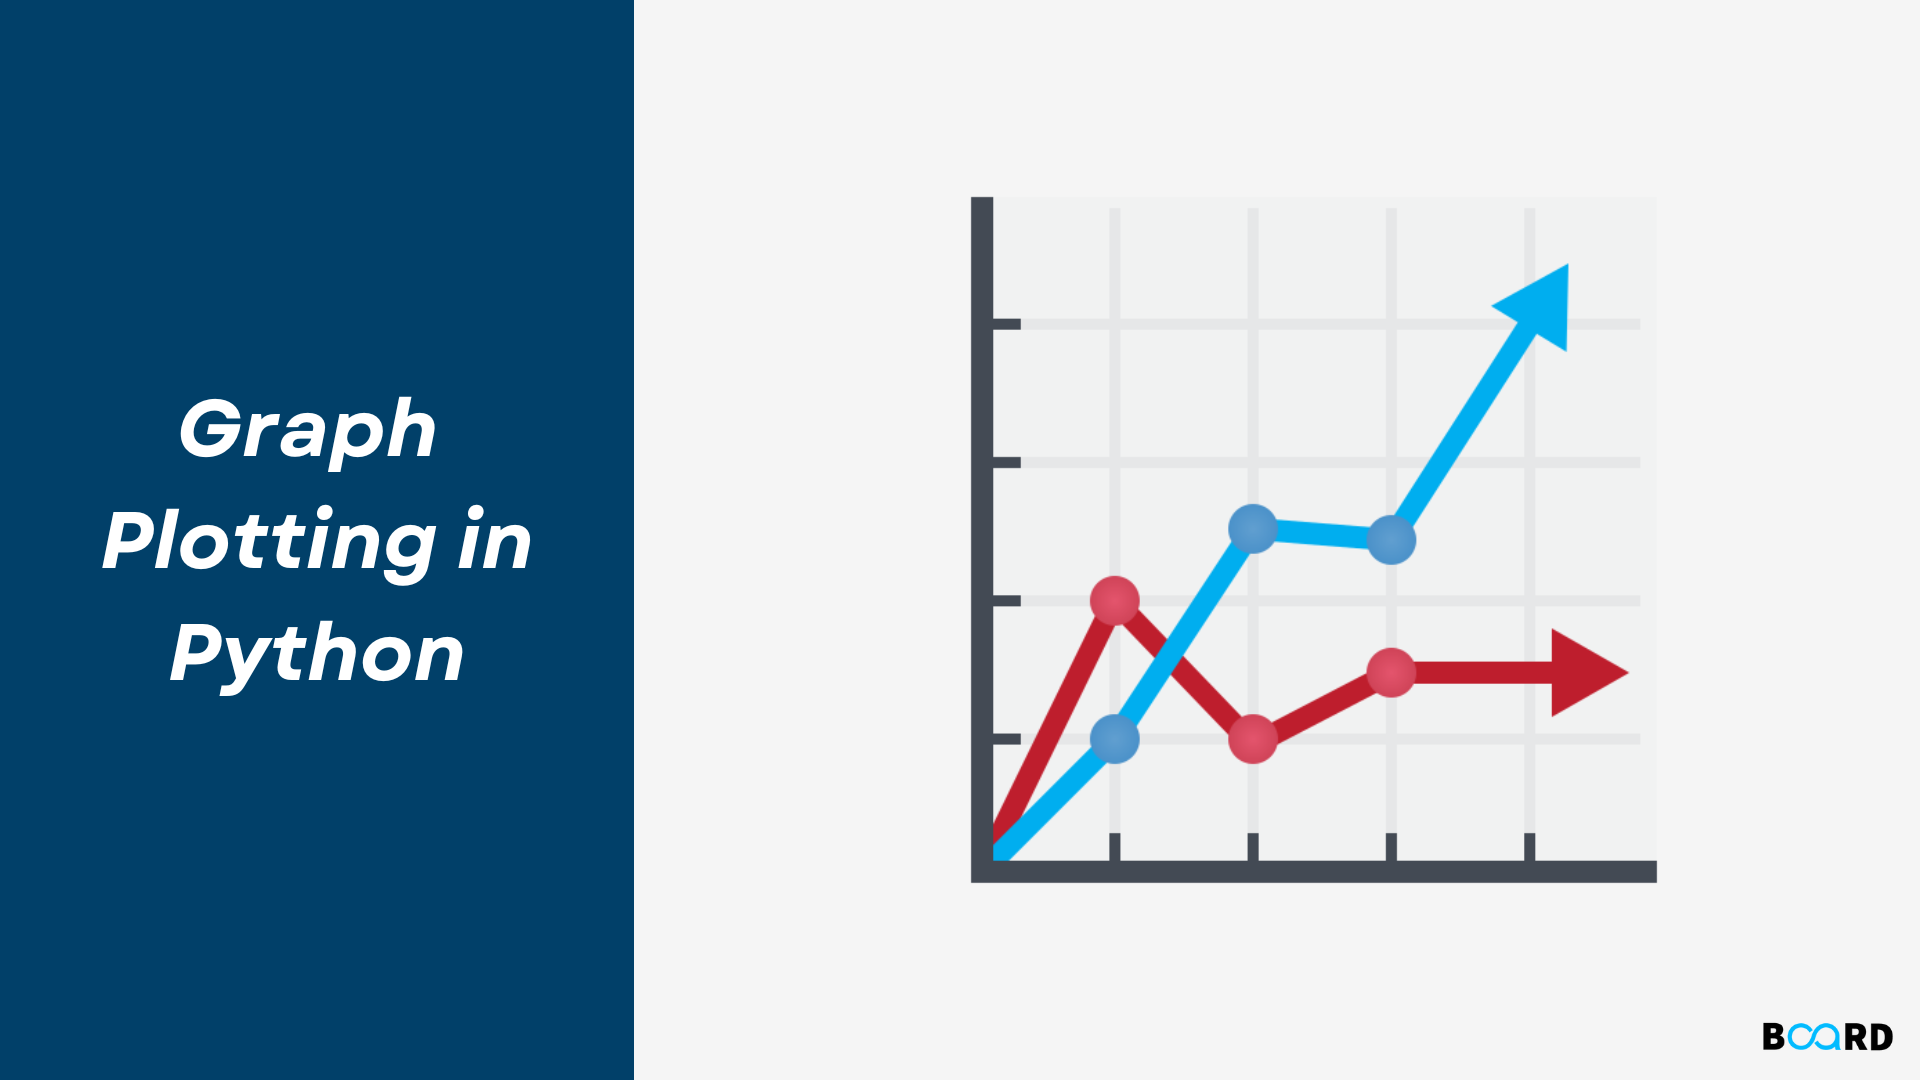


---

השערה:

מגמות הטמפרטורה לאורך זמן ישתנו עבור תנאי מזג אוויר שונים, כאשר תנאים מסוימים מראים יותר שונות. לדוגמה, מזג אוויר בהיר עשוי להראות טמפרטורות יציבות יותר וגבוהות יותר, בעוד שתנאי גשם או שלג עשויים להראות יותר תנודות וטמפרטורות נמוכות יותר.


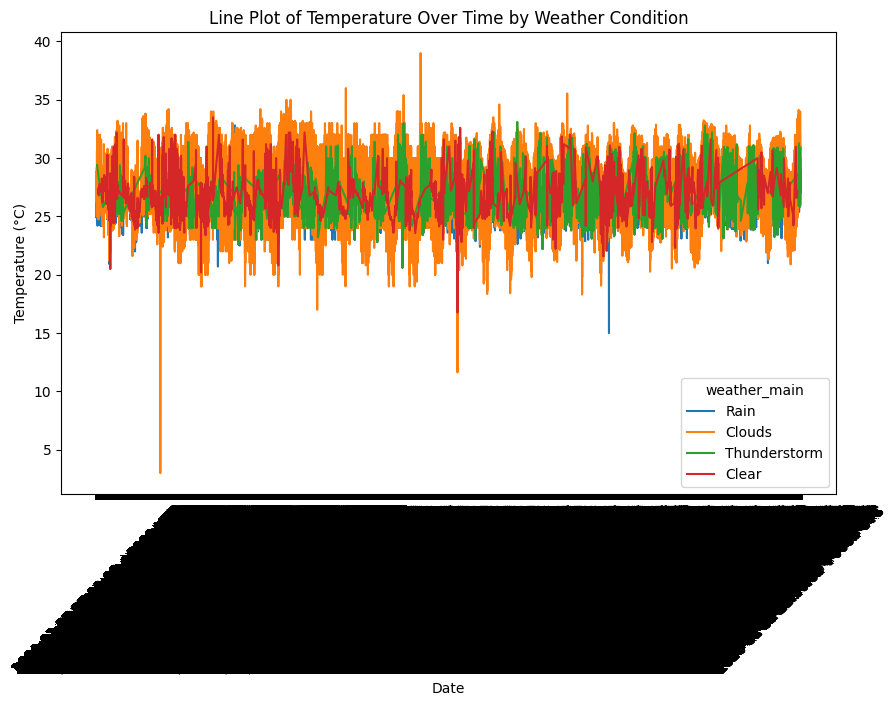

In [ ]:
# Line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='dt_iso', y='temp', hue='weather_main', data=df)
plt.title('Line Plot of Temperature Over Time by Weather Condition')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.show()

מסקנה:

עלילת הקו מראה כי דפוסי הטמפרטורה משתנים בהתאם לתנאי מזג האוויר. למזג אוויר בהיר יש טמפרטורות יציבות יותר וגבוהות יותר, בעוד שתנאי גשם/שלג מראים יותר שונות וטמפרטורות נמוכות יותר בסך הכל. העלילה גם מדגישה את שינויי הטמפרטורה העונתיים בכל התנאים.


---



השערה:

תנאי מזג אוויר שונים (למשל, בהיר, מעונן, גשום) יציגו דפוסים ברורים ביחס בין טמפרטורה ללחות.

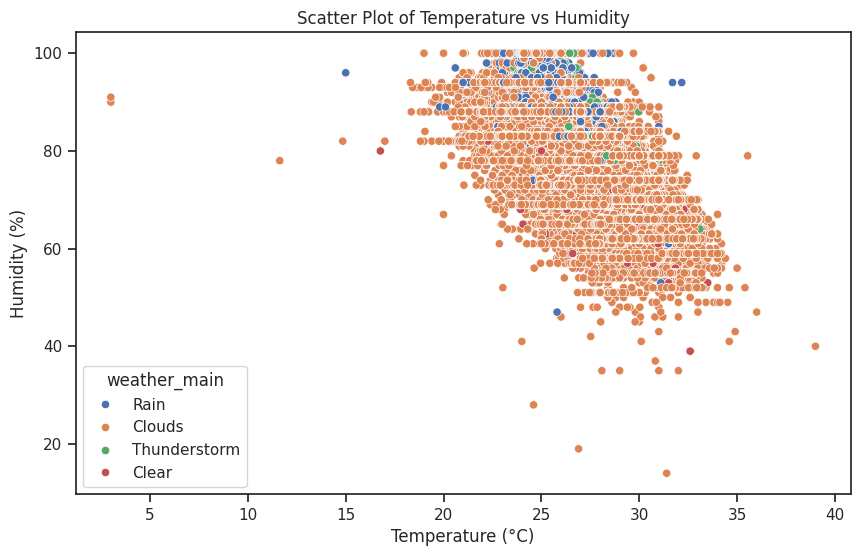

In [ ]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='humidity', hue='weather_main', data=df)
plt.title('Scatter Plot of Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.show()

מסקנה:

עלילת הפיזור מציגה אשכולות ברורים לתנאי מזג אוויר שונים. לדוגמה, מזג אוויר בהיר נוטה לקבל טמפרטורות גבוהות יותר ולחות נמוכה יותר, בעוד מזג אוויר גשום מציג רמות לחות גבוהות יותר. זה מאשש את ההשערה שתנאי מזג אוויר שונים מציגים דפוסים  ייחודיים בטמפרטורה ולחות.


---



השערה:

.התפלגות הטמפרטורה תשתנה באופן משמעותי בין תנאי מזג אוויר שונים

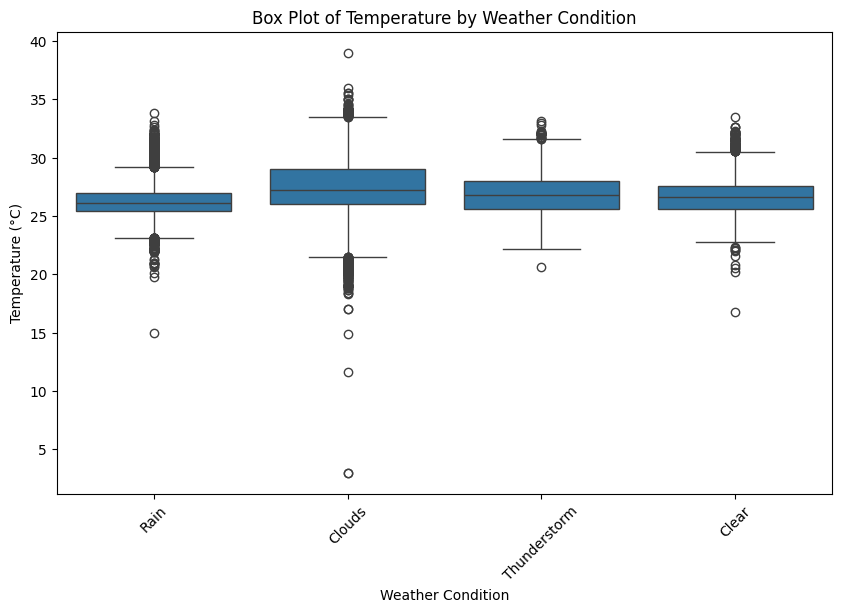

In [ ]:
# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='weather_main', y='temp', data=df)
plt.title('Box Plot of Temperature by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.show()

מסקנה:

עלילת הקופסה מגלה שהתפלגות הטמפרטורה משתנות בתנאי מזג אוויר שונים. לדוגמה, במזג אוויר בהיר יש בדרך כלל טמפרטורות גבוהות יותר, בעוד שבתנאי גשם ושלג יש טמפרטורות נמוכות יותר. זה תומך בהשערה שחלוקת הטמפרטורה מושפעת מתנאי מזג האוויר.


---



השערה:

התפלגות מהירות הרוח תהיה שונה בין תנאי מזג אוויר שונים, כאשר תנאי סערה יראו מהירויות רוח גבוהות יותר.

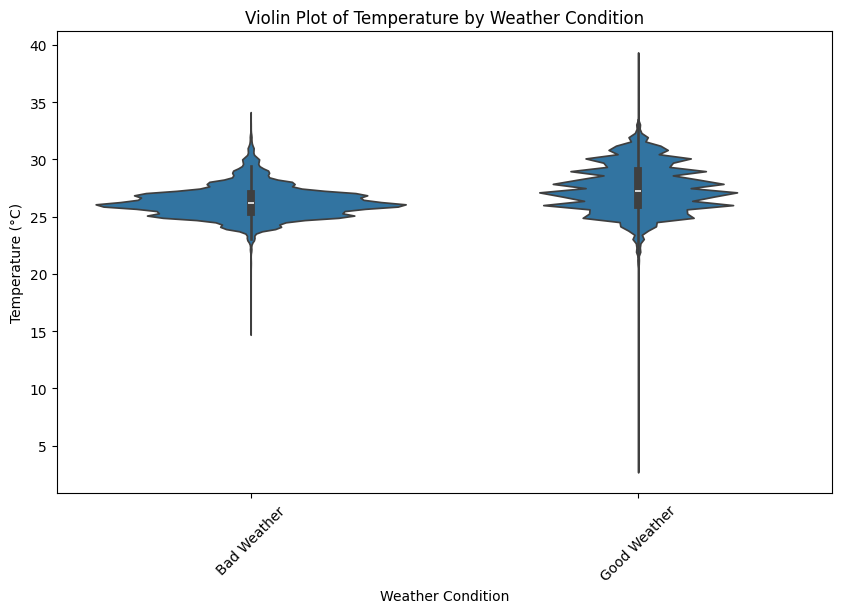

In [ ]:
# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='weather_category', y='temp', data=df)
plt.title('Violin Plot of Temperature by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.show()



---


השערה:

הטמפרטורה תראה דפוס עונתי, עם טמפרטורות גבוהות יותר בחודשי הקיץ וטמפרטורות נמוכות יותר בחודשי החורף.

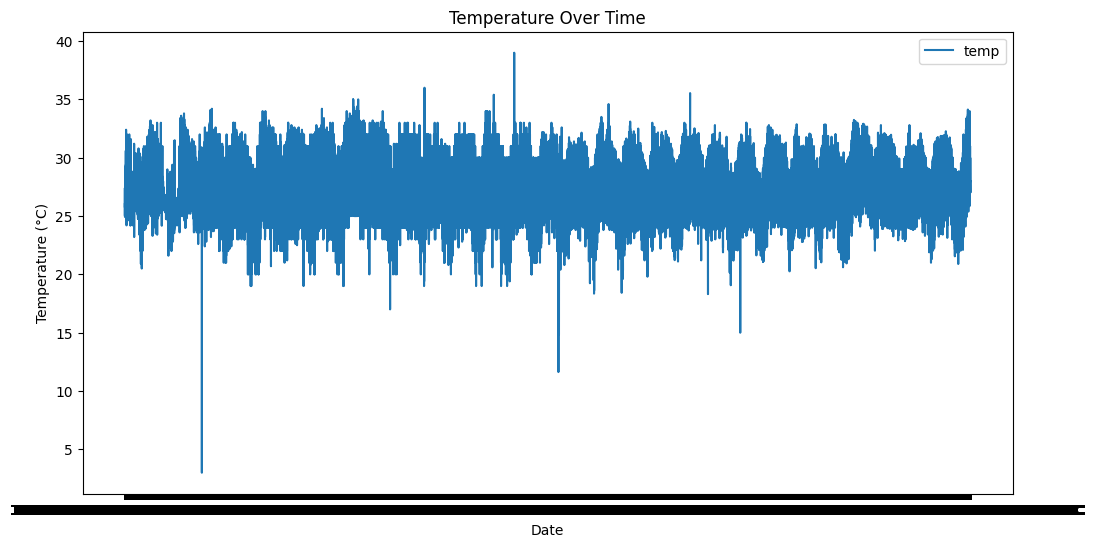

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['dt_iso'], df['temp'], label='temp')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time')
plt.legend()
plt.show()

מסקנה:

הגרף מאשר את ההשערה, מראה מגמה עונתית ברורה. הטמפרטורה מגיעה לשיא במהלך חודשי הקיץ ויורדת בחודשי החורף, מה שמעיד על דפוס אקלים ממוזג טיפוסי.


---



השערה:

יהיה מתאם חיובי בין טמפרטורה ללחות, שכן טמפרטורות גבוהות יותר עלולות להוביל לרמות לחות גבוהות יותר.

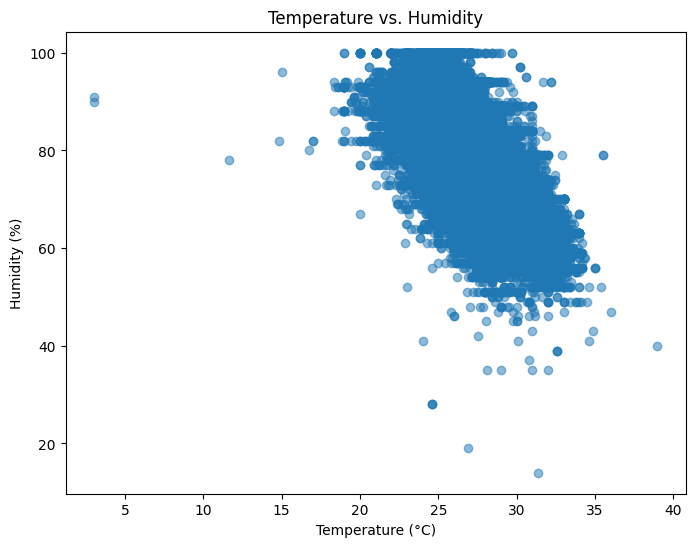

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['temp'], df['humidity'], alpha=0.5)
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs. Humidity')
plt.show()

מסקנה:

עלילת הפיזור מראה מתאם חיובי בין טמפרטורה ללחות. ככל שהטמפרטורה עולה, גם רמות הלחות נוטות לעלות. זה מאשש את ההשערה שטמפרטורות גבוהות יותר קשורות לרמות לחות גבוהות יותר.


---



השערה:

יהיו מתאמים משמעותיים בין פרמטרי מזג אוויר שונים כגון טמפרטורה (טמפ', temp_min, temp_max), לחץ, לחות, מהירות רוח (מהירות_רוח) וכיוון הרוח (wind_deg). פרמטרים מסוימים עשויים להפגין מתאם חיובי או שלילי חזק יותר מאחרים.

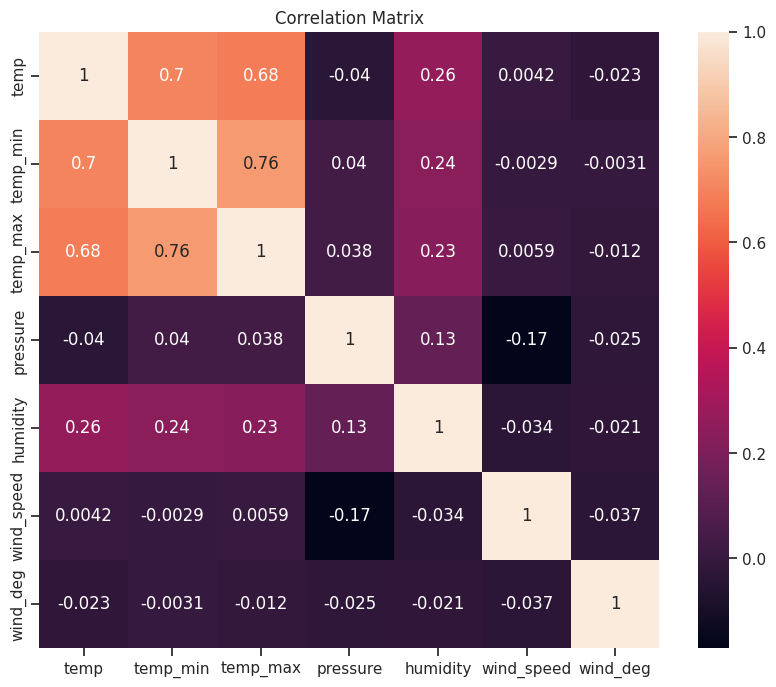

In [ ]:
correlation = df[['temp','temp_min','temp_max','pressure','humidity','wind_speed','wind_deg']].apply(lambda x: pd.factorize(x) [0]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='rocket')
plt.title('Correlation Matrix')
plt.show()

מסקנה:

מפת החום מאשרת את ההשערה שיש מתאם משמעותי בין פרמטרי מזג אוויר שונים, כאשר טמפרטורה ולחות הם המשתנים המתואמים ביותר. מידע זה יכול להיות שימושי להבנת הקשרים בין גורמי מזג אוויר שונים ולשיפור פוטנציאל של מודלים לחיזוי מזג אוויר.

---
**checking the precentages between every type**

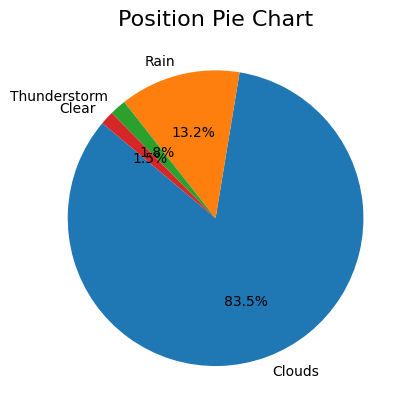

In [ ]:
sizes = df['weather_main'].value_counts()
labels = sizes.index
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title("Weather Condition Proportions",fontsize = 16);

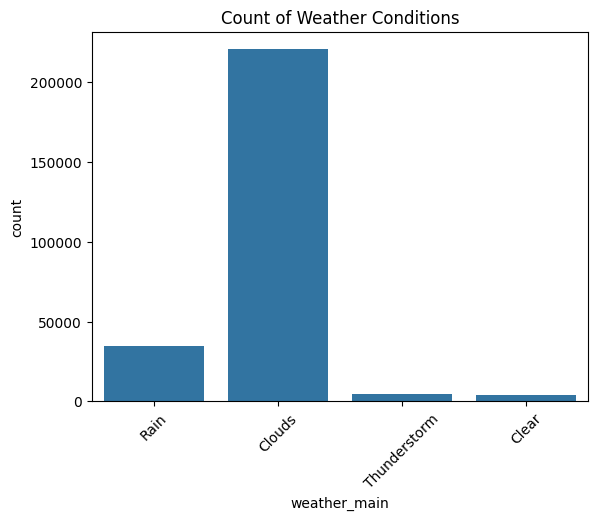

In [ ]:
sns.countplot(x='weather_main', data=df)
plt.title('Count of Weather Conditions')
plt.xticks(rotation=45)
plt.show()



---


#KNN

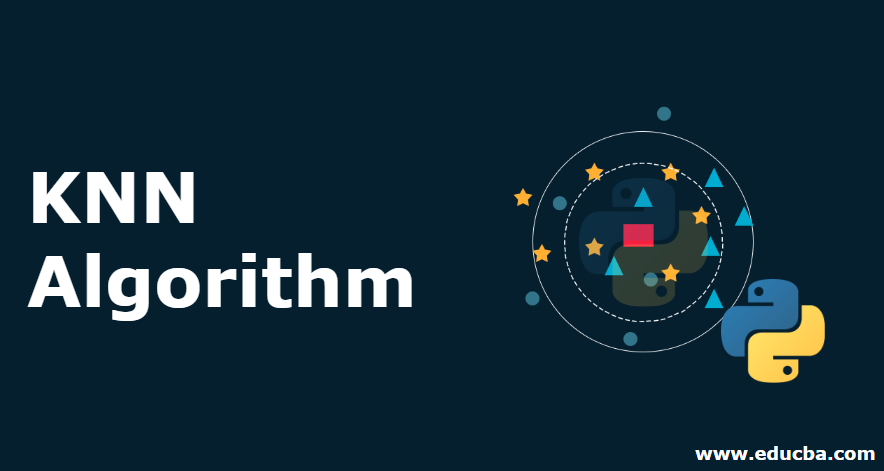

trying various variables

In [ ]:
X = df[['lon','lat','temp','temp_min','temp_max']]
y = df[['weather_main']].values.ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
neigh = KNeighborsClassifier(n_neighbors=6)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80)

In [ ]:
X_Train, X_Test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train = y_train.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
y_test = y_test.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
scaler = MinMaxScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)
max_accur = 0.0
for k in range(3, 20, 2):
    knn1 = KNeighborsClassifier(n_neighbors=k)
    knn1.fit(X_Train, y_train)
    accur = knn1.score(X_Test, y_test)
    if accur > max_accur:
        max_accur = accur
        best_k = k
    print("Accuracy for k=", k, " is ", accur, " Cross Validation value is ", np.mean(cross_val_score(knn1, X_Test, y_test, cv=5)))

Accuracy for k= 3  is  0.8088939350931971  Cross Validation value is  0.7951745671302868
Accuracy for k= 5  is  0.8210615952313369  Cross Validation value is  0.8172390954678779
Accuracy for k= 7  is  0.8302393793168701  Cross Validation value is  0.8221591446683698
Accuracy for k= 9  is  0.8273251963288863  Cross Validation value is  0.8314693916169931
Accuracy for k= 11  is  0.8282145898382061  Cross Validation value is  0.8317721638754849
Accuracy for k= 13  is  0.829236446210616  Cross Validation value is  0.8326237108524932
Accuracy for k= 15  is  0.8338347998864604  Cross Validation value is  0.8336644904910587
Accuracy for k= 17  is  0.8334941810956571  Cross Validation value is  0.833721260289526
Accuracy for k= 19  is  0.8334752578295014  Cross Validation value is  0.8344024978711326


as we can see decent result for those variable

In [ ]:
X = df[['pressure','humidity','wind_speed','wind_deg']]
y = df[['weather_main']].values.ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
neigh = KNeighborsClassifier(n_neighbors=6)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80)

In [ ]:
X_Train, X_Test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train = y_train.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
y_test = y_test.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
scaler = MinMaxScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)
max_accur = 0.0
for k in range(3, 20, 2):
    knn1 = KNeighborsClassifier(n_neighbors=k)
    knn1.fit(X_Train, y_train)
    accur = knn1.score(X_Test, y_test)
    if accur > max_accur:
        max_accur = accur
        best_k = k
    print("Accuracy for k=", k, " is ", accur, " Cross Validation value is ", np.mean(cross_val_score(knn1, X_Test, y_test, cv=5)))

Accuracy for k= 3  is  0.8318857034724193  Cross Validation value is  0.8234080802346485
Accuracy for k= 5  is  0.8397767054593623  Cross Validation value is  0.836332671019018
Accuracy for k= 7  is  0.8446589081275429  Cross Validation value is  0.8412337969533542
Accuracy for k= 9  is  0.8468918535339199  Cross Validation value is  0.8431639701012393
Accuracy for k= 11  is  0.847535244583215  Cross Validation value is  0.8448481407891002
Accuracy for k= 13  is  0.8476298609139937  Cross Validation value is  0.8454915318383953
Accuracy for k= 15  is  0.8480083262371085  Cross Validation value is  0.8464187718800265
Accuracy for k= 17  is  0.8491815687387643  Cross Validation value is  0.8464376951461823
Accuracy for k= 19  is  0.849635727126502  Cross Validation value is  0.8463998486138706


as we can see very nice result for those variables



---


using only the variable "temp"

In [ ]:
X = df[['temp']]
y = df[['weather_main']].values.ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
neigh = KNeighborsClassifier(n_neighbors=6)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80)

In [ ]:
X_Train, X_Test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train = y_train.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
y_test = y_test.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
scaler = MinMaxScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)
max_accur = 0.0
for k in range(3, 20, 2):
    knn1 = KNeighborsClassifier(n_neighbors=k)
    knn1.fit(X_Train, y_train)
    accur = knn1.score(X_Test, y_test)
    if accur > max_accur:
        max_accur = accur
        best_k = k
    print("Accuracy for k=", k, " is ", accur, " Cross Validation value is ", np.mean(cross_val_score(knn1, X_Test, y_test, cv=5)))

Accuracy for k= 3  is  0.8041063487557952  Cross Validation value is  0.7908979089790897
Accuracy for k= 5  is  0.8201532784558615  Cross Validation value is  0.8143627590122055
Accuracy for k= 7  is  0.8260762607626077  Cross Validation value is  0.8210805184974926
Accuracy for k= 9  is  0.8280821269751159  Cross Validation value is  0.8254328697133125
Accuracy for k= 11  is  0.8289715204844356  Cross Validation value is  0.8286876714920997
Accuracy for k= 13  is  0.8297095278645095  Cross Validation value is  0.8300123001230013
Accuracy for k= 15  is  0.8298419907275996  Cross Validation value is  0.8321506291985997
Accuracy for k= 17  is  0.829595988267575  Cross Validation value is  0.83241555492478
Accuracy for k= 19  is  0.8296906045983536  Cross Validation value is  0.8323777083924686


conclusion:

very good results considering the fact that i used only one variable



---



In [ ]:
X = df[['lon','lat','temp','temp_min','temp_max','pressure','humidity','wind_speed','wind_deg']]
y = df[['weather_main']].values.ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
neigh = KNeighborsClassifier(n_neighbors=6)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80)

In [ ]:
X_Train, X_Test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train = y_train.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
y_test = y_test.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
scaler = MinMaxScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)
max_accur = 0.0
for k in range(3, 20, 2):
    knn1 = KNeighborsClassifier(n_neighbors=k)
    knn1.fit(X_Train, y_train)
    accur = knn1.score(X_Test, y_test)
    if accur > max_accur:
        max_accur = accur
        best_k = k
    print("Accuracy for k=", k, " is ", accur, " Cross Validation value is ", np.mean(cross_val_score(knn1, X_Test, y_test, cv=5)))

Accuracy for k= 3  is  0.840723707867295  Cross Validation value is  0.8280248122233911
Accuracy for k= 5  is  0.8471204981169213  Cross Validation value is  0.8426541425905152
Accuracy for k= 7  is  0.8496375783039043  Cross Validation value is  0.8458336309309107
Accuracy for k= 9  is  0.8511137606692026  Cross Validation value is  0.8481614541062985
Accuracy for k= 11  is  0.8521357330759477  Cross Validation value is  0.8494294472379018
Accuracy for k= 13  is  0.8524763905448627  Cross Validation value is  0.8510381075100829
Accuracy for k= 15  is  0.8520978822460682  Cross Validation value is  0.8513787710687444
Accuracy for k= 17  is  0.8525142413747422  Cross Validation value is  0.8521925413462433
Accuracy for k= 19  is  0.8530630784079941  Cross Validation value is  0.8521546733231096




---
**Activating the confusion matrix to see the prediction and the accuracy**

Accuracy for the best k - 19  is  0.8530630784079941
              precision    recall  f1-score   support

       Clear     0.7500    0.0038    0.0076       785
      Clouds     0.8679    0.9778    0.9196     44191
        Rain     0.6109    0.2697    0.3742      6893
Thunderstorm     0.5000    0.0010    0.0021       970

    accuracy                         0.8531     52839
   macro avg     0.6822    0.3131    0.3259     52839
weighted avg     0.8259    0.8531    0.8180     52839



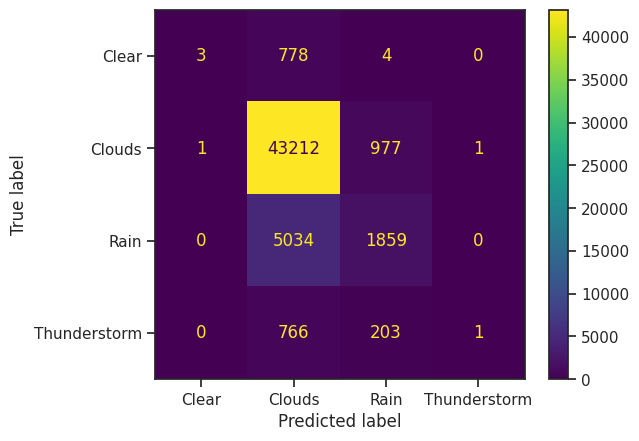

In [ ]:
knn1 = KNeighborsClassifier(n_neighbors=best_k)
knn1.fit(X_Train,y_train)
print ("Accuracy for the best k -",best_k," is ",knn1.score(X_Test,y_test))

ConfusionMatrixDisplay.from_estimator(knn1, X_Test, y_test)
pred1 = knn1.predict(X_Test)
print (classification_report(y_test,pred1,digits=4))

conclusion:

As we can see the prediction was very accurate with an accuracy of 0.8531


---



# SVM

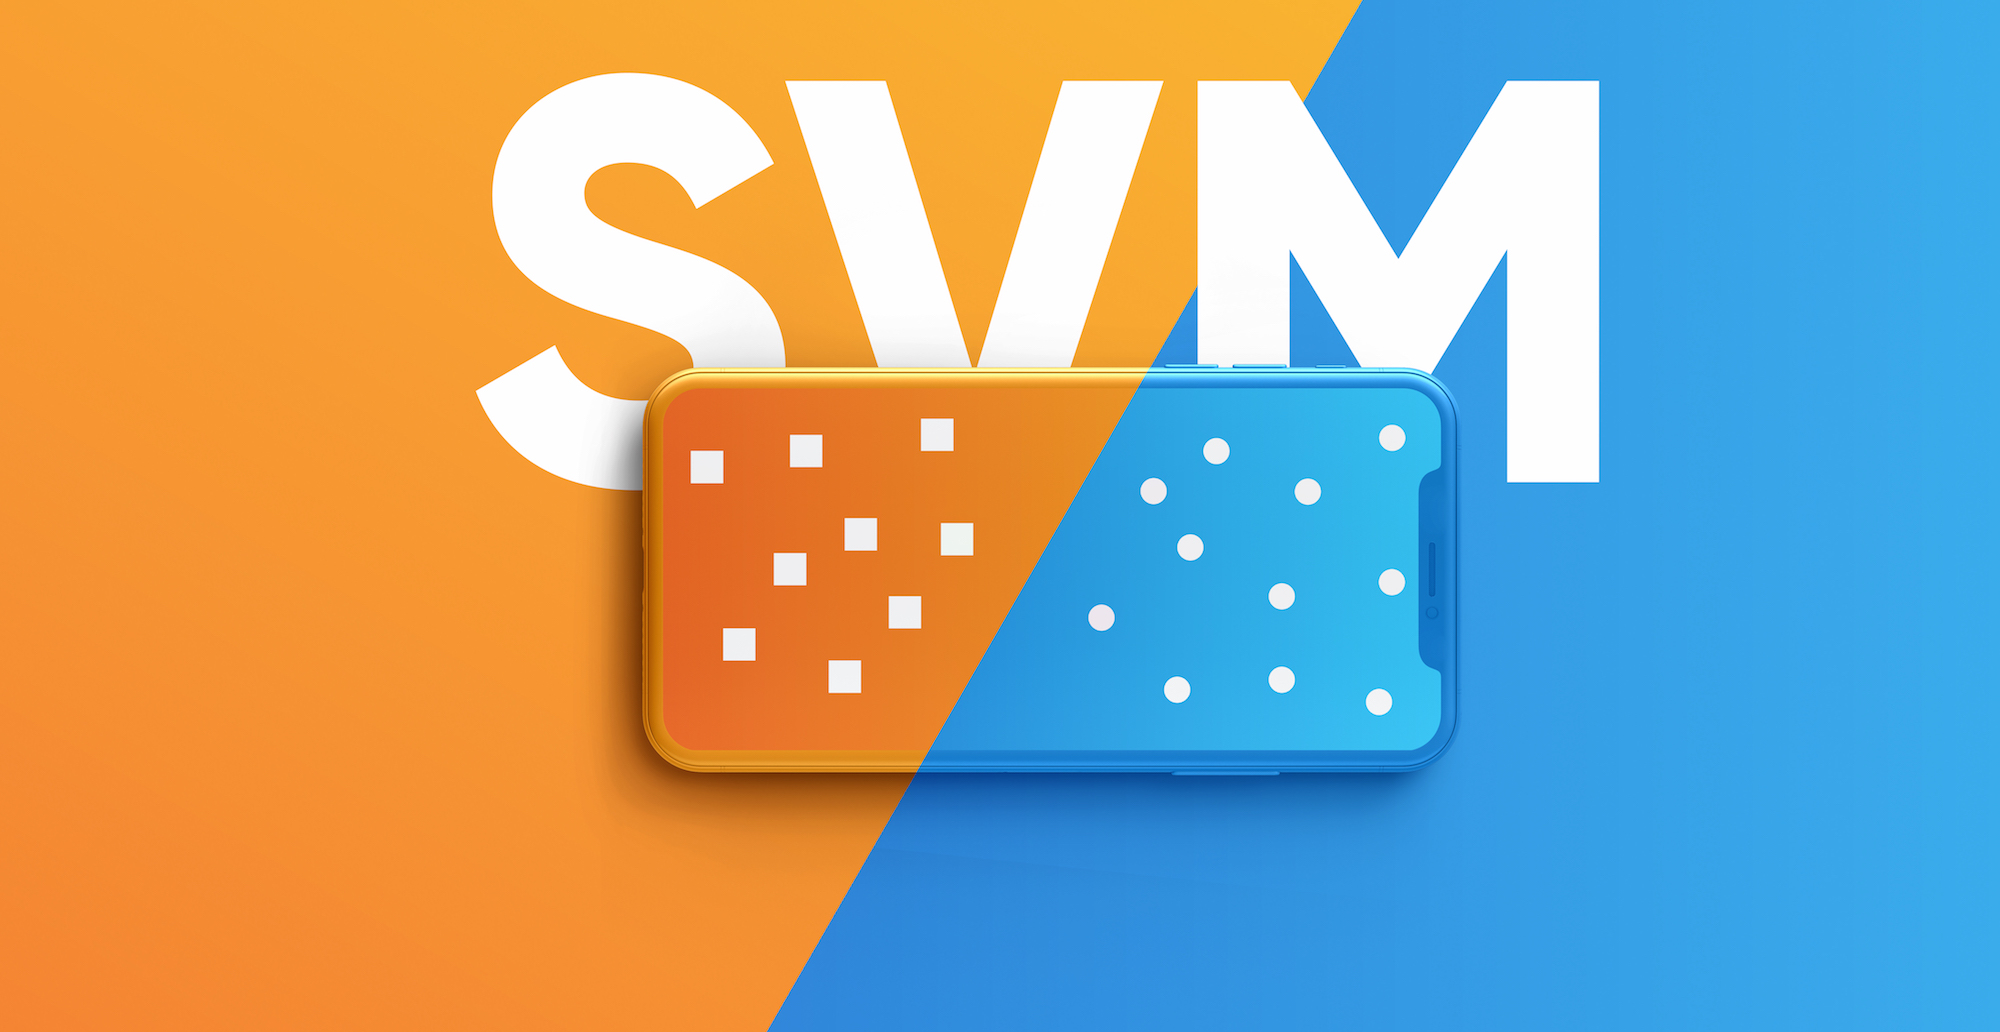



---
Using 25% of the dataframe to make the process faster


In [ ]:
X_Train_subset = X_Train[:66250]
y_train_subset = y_train[:66250]

In [ ]:
max_c=0
best_score=0
for c in range(10,100,10):
    svm=SVC(kernel='linear',C=c)
    svm.fit(X_Train_subset,y_train_subset)
    score = svm.score(X_Test, y_test)
    if (score>best_score):
      max_c=c
      best_score=score
print("max_c = {} score test: {}".format(max_c,best_score))

max_c = 10 score test: 0.8354054309773867


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       Clear     0.0000    0.0000    0.0000       799
      Clouds     0.8354    1.0000    0.9103     44147
        Rain     0.0000    0.0000    0.0000      6952
Thunderstorm     0.0000    0.0000    0.0000       947

    accuracy                         0.8354     52845
   macro avg     0.2089    0.2500    0.2276     52845
weighted avg     0.6979    0.8354    0.7605     52845



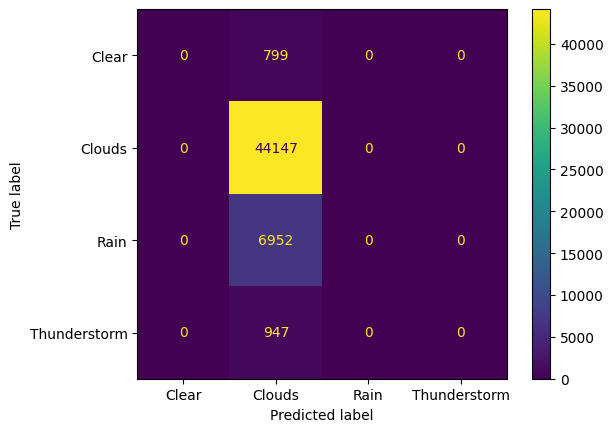

In [ ]:
svm1 = SVC(kernel='linear',C=max_c)
svm1.fit(X_Train_subset,y_train_subset)
ConfusionMatrixDisplay.from_estimator(svm1, X_Test, y_test)
pred1 = svm1.predict(X_Test)
print (classification_report(y_test,pred1,digits=4))



---


**rbf:** Using only 10% of the dataframe to make the process faster

In [ ]:
X_Train_subset = X_Train[:26000]
y_train_subset = y_train[:26000]

In [ ]:
max_c=0
best_score=0
for c in range(10,100,10):
    svm=SVC(kernel='rbf',C=c)
    svm.fit(X_Train_subset,y_train_subset)
    score = svm.score(X_Test, y_test)
    if (score>best_score):
      max_c=c
      best_score=score
print("max_c = {} score test: {}".format(max_c,best_score))

max_c = 80 score test: 0.8492590700051099


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       Clear     0.0000    0.0000    0.0000       794
      Clouds     0.8534    0.9925    0.9177     44215
        Rain     0.6999    0.1426    0.2369      6936
Thunderstorm     0.0000    0.0000    0.0000       894

    accuracy                         0.8493     52839
   macro avg     0.3883    0.2838    0.2887     52839
weighted avg     0.8060    0.8493    0.7990     52839



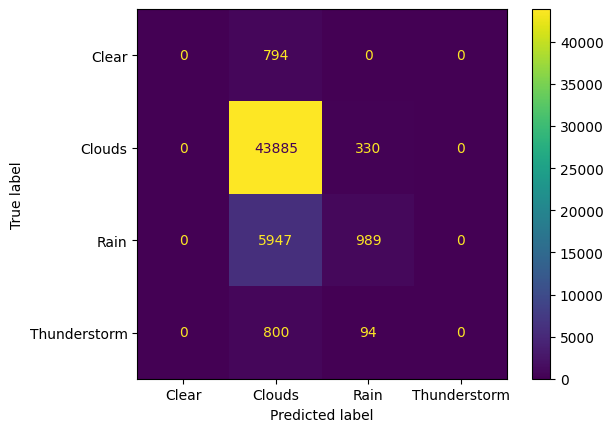

In [ ]:
svm1 = SVC(kernel='rbf',C=max_c)
svm1.fit(X_Train_subset,y_train_subset)
ConfusionMatrixDisplay.from_estimator(svm1, X_Test, y_test)
pred1 = svm1.predict(X_Test)
print (classification_report(y_test,pred1,digits=4))

מסקנה:

אשפר לראות שהמטריצה השנייה הייתה יותר טובה באחוז אחד שזה לא באמת משמעותי rbf

In [ ]:
scaler = MinMaxScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)



---


**linear:** Using only 20,000 rows to make the process faster

In [ ]:
X_Train_subset = X_Train[:20000]
y_train_subset = y_train[:20000]

In [ ]:
max_c=0
best_score=0
for c in range(10,100,10):
    svm=SVC(kernel='linear',C=c)
    svm.fit(X_Train_subset,y_train_subset)
    score = svm.score(X_Test, y_test)
    if (score>best_score):
      max_c=c
      best_score=score
print("max_c = {} score test: {}".format(max_c,best_score))

max_c = 10 score test: 0.8354054309773867


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       Clear     0.0000    0.0000    0.0000       799
      Clouds     0.8354    1.0000    0.9103     44147
        Rain     0.0000    0.0000    0.0000      6952
Thunderstorm     0.0000    0.0000    0.0000       947

    accuracy                         0.8354     52845
   macro avg     0.2089    0.2500    0.2276     52845
weighted avg     0.6979    0.8354    0.7605     52845



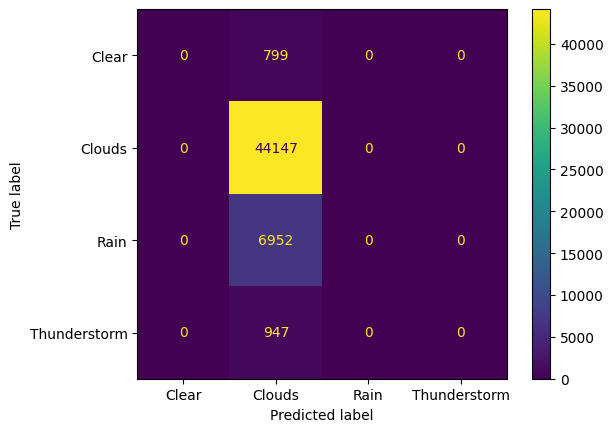

In [ ]:
svm1 = SVC(kernel='linear',C=max_c)
svm1.fit(X_Train_subset,y_train_subset)
ConfusionMatrixDisplay.from_estimator(svm1, X_Test, y_test)
pred1 = svm1.predict(X_Test)
print (classification_report(y_test,pred1,digits=4))



---



In [ ]:
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5, 7, 9]}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'n_neighbors': 9}
0.8323286983140884




---


בחינת הביצועים של


KNN AND SVM

In [ ]:
# Calculate accuracy scores for KNN model
knn_accuracies = []
for k in range(3, 10, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_preds = knn.predict(X_test)
    knn_accuracies.append(accuracy_score(y_test, knn_preds))

In [ ]:
# Calculate accuracy scores for SVM model
svm_accuracies = []
for c in range(10, 101, 10):
    svc = SVC(C=c/10) # Use C values from 1 to 10
    svc.fit(X_Train_subset,y_train_subset)
    svm_preds = svc.predict(X_test)
    svm_accuracies.append(accuracy_score(y_test, svm_preds))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has fe

Text(0.5, 0, 'K value (for C multiply by')

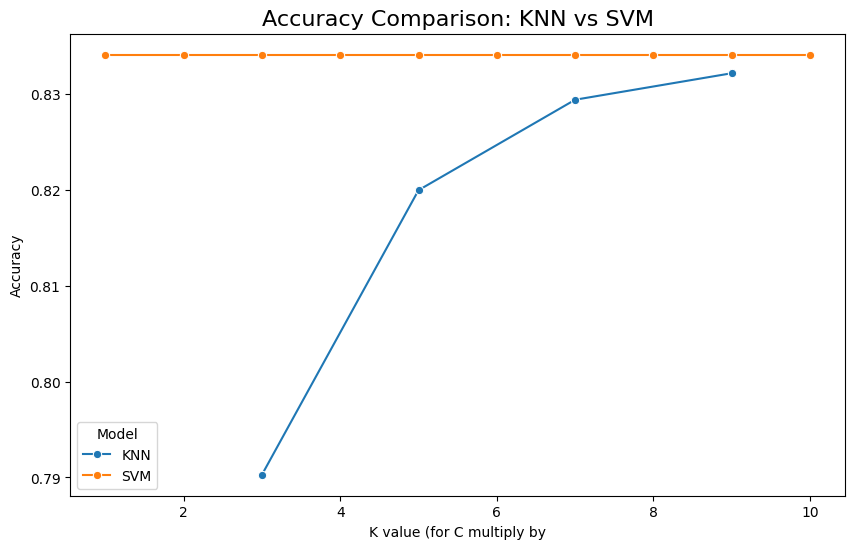

In [ ]:
data = {
    'Model': ['KNN'] * len(knn_accuracies) + ['SVM'] * len(svm_accuracies),
    'Value': list(range(3, 10, 2)) + [c/10 for c in range(10, 101, 10)],
    'Accuracy': knn_accuracies + svm_accuracies
}


#יצרית מסד נתונים עם המידע
newdf = pd.DataFrame(data)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Value', y='Accuracy', hue='Model', marker='o')
#יצירת גרף עם המידע ממסד הנתונים
plt.title('Accuracy Comparison: KNN vs SVM', fontsize=16)
plt.xlabel('K value (for C multiply by')

אפשר לראות לפי הגרף את הבדלי אחוזי הדיוק בין

KNN AND SVM

# Summary

**רפלקציה**

**הסברים על בחירת הנתונים**

**Y-כשבחרתי את ה**

**שלי, ידעתי שזה יהיה נושא טוב ומעניין, כי הוא מתייחס למשהו מהחיים
האמיתיים. הפרויקט שלי מתמקד בחיזוי אירועי מזג האוויר על בסיס נתונים שונים. הנתונים שבחרתי עבור המודל הם רלוונטיים, שכן הם משפיעים בצורה משמעותית על חיזוי מזג האוויר. לדוגמה, נתונים כמו טמפרטורה, לחות ולחץ אטמוספרי הם גורמים מכריעים בחיזוי תנאי מזג האוויר. השימוש בנתונים אלו מאפשר למודל שלי ללמוד את ההשפעות השונות ולהסיק מסקנות מדויקות יותר.**



---

**התנסות אישית**

**בחירת הנושא של מזג האוויר באה מהמחשבה של "איזה נושא אני יכול לבחור שאני שומע עליו בכל יום?" ואז עלה לי הרעיון של תחזית מזג האוויר שרואים את התחזית של השבוע הקרוב ואפשר לראות האם יהיו אירועים מעניינים של מזג האוויר. כשהתחלנו לדבר על הפרויקט הזה בתחילת השנה, חשבתי שזה לא אפשרי להוציא לפועל פרויקט כל כך גדול ומשמעותי. עם זאת, נהניתי מאוד מהפרויקט הזה והצלחתי להתגבר על האתגרים שניצבו בפניי. אחד האתגרים היה התמודדות עם יצירת הגרפים**

**אתגר נוסף היה הבחירה וההכנה של המאפיינים (features) עבור המודל. היה עלי להחליט אילו מאפיינים לכלול ואילו להוציא, וכן להתמודד עם נורמליזציה של הנתונים כדי להבטיח שהמודל ילמד בצורה הטובה ביותר. תהליך זה דרש הבנה מעמיקה של הנתונים והשפעתם על המודל.**

**דרך התהליך הזה, למדתי הרבה על ניהול ועיבוד נתונים, יצירת מאפיינים. עד כמה חשוב לבצע חקר נתונים מקיף כדי להפיק תובנות משמעותיות ולהכין את הנתונים בצורה הטובה ביותר למודל.**

**בסופו של דבר, הפרויקט הזה העשיר את הידע שלי בתחום למידת מכונה. ועכשיו אני יוצא עם ידע על הנושא ועם פרויקט חיזוי מזג האוויר.**